# Data connection

먼저 ‘Data connection’에 대해 설명하자면, Data connection은 LLM과 외부의 데이터를 연결하기 위한 기능이다.

대형 언어 모델(LLM)은 사전에 학습된 데이터만을 기반으로 답변을 생성합니다.<br />
따라서 모델이 학습을 마친 시점 이후의 최신 정보나, 기업 내부 문서와 같은 비공개·사적 데이터에 대해서는 알지 못한다는 한계가 있습니다.<br />
만약 모델이 모르는 정보에 대해 질문을 던진다면, 모른다고 답변하거나 심한 경우 그럴싸하지만 완전히 거짓인 답변을 만들어내는 할루시네이션(Hallucination, 환각 현상)이 발생하게 됩니다.<br />
이러한 문제를 해결하기 위해 등장한 개념이 바로 프롬프트에 외부 참고 자료(Context)를 함께 넣어주는 RAG(검색 증강 생성)이며, 이 과정에서 외부 데이터를 LLM이 이해할 수 있도록 연결해 주는 핵심 기술이 Data Connection입니다.

In [ ]:
GPT 프롬프트에서 질문하기
아래 두 문장을 각각 프롬프트로 물어 보기

In [ ]:
LangChain이란?

In [ ]:
랭체인의 README (https://github.com/langchain-ai/langchain/blob/master
/README.md)의) 내용을 컨텍스트(context)에 포함시켜 질문해 보겠다.

In [ ]:
문맥을 고려하여 한 문장으로 질문에 답해 주세요.

문맥: """
<랭체인의 README 내용>
"""

질문: LangChain이란 무엇인가요?

문맥을 마탕으로 대답을 하는 것을 알 수 있다.<br />
이렇게 질문과 관련된 문서의 내용을 컨텍스트에 포함시킴으로써 LLM이 본래 알지 못하는 것을 답변하게 할 수 있다.<br />
단, LLM은 토큰 수에 제한이 있기 때문에 모든 데이터를 컨텍스트에 담을 수는 없다.<br />
입력과 관련이 있을 것 같은 문서를 검색하여 컨텍스트에 포함시키는 방법이 있다<br />
문서를 Embeddings API 등으로 벡터화해 입력과 벡터가 가까운 문서를 검색하여 컨텍스트에 포함시키는 기법을 RAG(Retrieval Augmented Generation)¹라고 한다.<br />
문서는 미리 준비된 데이터베이스에서 검색할 수도 있고, 구글과 같은 검색엔진으로 웹상에서 검색할 수도 있다<br />

랭체인의 Data connection에서는 특히 벡터 스토어(Vector store)를 사용하여 문서를 벡터화하여 저장해 두었다가 입력된 텍스트와 벡터에 가까운 문서를 검색하여 컨텍스트에 포함시켜 사용하는 방법을 제공한다.<br />
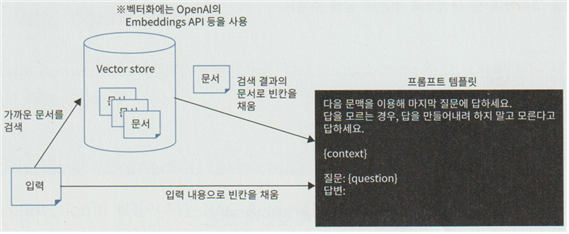

### Data connection 개요
RAG에 사용할 수 있는 랭체인의 모듈은 ‘Data connection’이다. <br />
* Document loaders: 데이터 소스로부터 문서를 불러온다. <br />
* Document transformers: 문서에 어떤 종류의 변환을 가한다. <br />
* Text embedding models: 문서를 벡터화한다. <br />
* Vector stores: 벡터화된 문서를 저장할 수 있는 저장소 <br />
* Retrievers: 입력한 텍스트와 관련된 문서를 검색한다. <br />
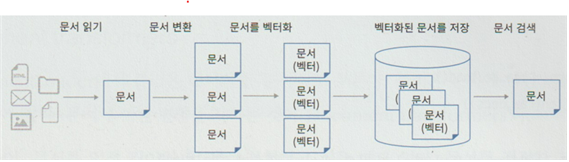

### 1. Document loaders
데이터 로딩에 사용하는 것이 ‘Document loaders’다.

In [9]:
# 여기서는 깃허브 저장소에 공개된 문서를 불러오기로 한다. 먼저 GitPython이라는 패키지가 필요하므로 설치한다.
!pip install langchain-community GitPython==3.1.36

  Attempting uninstall: GitPython
    Found existing installation: GitPython 3.1.50
    Uninstalling GitPython-3.1.50:
      Successfully uninstalled GitPython-3.1.50


In [10]:
# !pip install langchain-community GitPython

# 임포트 경로를 langchain_community로 수정합니다.
from langchain_community.document_loaders import GitLoader

def file_filter(file_path):
    return file_path.endswith(".md")

loader = GitLoader(
    clone_url="https://github.com/langchain-ai/langchain",
    repo_path="./langchain",
    branch="master",
    file_filter=file_filter,
)

raw_docs = loader.load()
print(f"가져온 마크다운 문서 개수: {len(raw_docs)}")

가져온 마크다운 문서 개수: 29


표) 랭체인의 DocumentLoader (일부)<br />
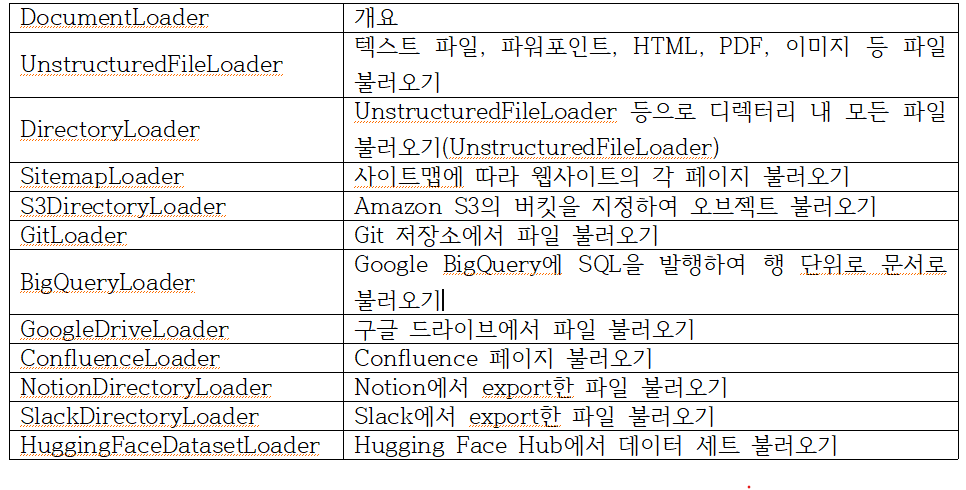

## 인터넷(깃허브)에 있는 거대한 코드 저장소를 AI가 읽을 수 있는 책(Document 객체) 형태로 내 컴퓨터에 자동 다운로드 및 변환해 주는 아주 강력한 수집 예제

In [12]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

from langchain_community.document_loaders import GitLoader

# 1. 파일 필터 함수 정의
# 저장소 안에서 확장자가 '.py'인 파이썬 코드 파일만 골라내도록 설정합니다.
def python_file_filter(file_path):
    return file_path.endswith(".py")

# 2. GitLoader 객체 생성
# clone_url의 저장소를 로컬의 repo_path 경로로 복사(Clone)해 옵니다.
loader = GitLoader(
    clone_url="https://github.com/langchain-ai/langchain", # 복사할 깃허브 주소
    repo_path="./langchain_repo",                         # 로컬에 저장될 폴더 경로
    branch="master",                                      # 가져올 브랜치 이름
    file_filter=python_file_filter                        # 위에서 만든 필터 함수 적용
)

print("깃허브에서 저장소를 다운로드(Clone) 중입니다... 잠시만 기다려 주세요.")

# 3. 데이터 로드 실행
# 로드가 완료되면 각 파일의 내용이 'Document' 객체 리스트로 담깁니다.
documents = loader.load()

print("다운로드 및 로드가 완료되었습니다!")
print(f"가져온 파이썬 파일 총 개수: {len(documents)}개\n")

# =====================================================================
# 4. 가져온 문서 구조 뜯어보기 (첫 번째 파일 샘플 확인)
# =====================================================================
if documents:
    first_doc = documents[0]
    
    print("==================================================")
    print("📄 [첫 번째 파일 메타데이터 정보]")
    print("==================================================")
    # metadata 안에는 파일 경로, 파일 이름, 소스 타입 등이 딕셔너리로 들어있습니다.
    print(f"파일 경로: {first_doc.metadata.get('file_path')}")
    print(f"파일 이름: {first_doc.metadata.get('file_name')}")
    
    print("\n==================================================")
    print("[첫 번째 파일 실제 내용 (앞부분 300자)]")
    print("==================================================")
    # page_content에 코드 내용 전체가 문자열(String)로 들어있습니다.
    print(first_doc.page_content[:300])
else:
    print("조건에 맞는 파일이 존재하지 않습니다.")

깃허브에서 저장소를 다운로드(Clone) 중입니다... 잠시만 기다려 주세요.
다운로드 및 로드가 완료되었습니다!
가져온 파이썬 파일 총 개수: 2531개

📄 [첫 번째 파일 메타데이터 정보]
파일 경로: .github\scripts\check_diff.py
파일 이름: check_diff.py

[첫 번째 파일 실제 내용 (앞부분 300자)]
"""Analyze git diffs to determine which directories need to be tested.

Intelligently determines which LangChain packages and directories need to be tested,
linted, or built based on the changes. Handles dependency relationships between
packages, maps file changes to appropriate CI job configuration


### 2. Document transformers

DocumentLoader에서 불러온 데이터를 ‘문서’라고 부른다.<br />
불러온 문서에 어떤 변환을 가하는 경우가 많다.<br /> 
문서에 어떤 변환을 가하는 것이 ‘Document transformers’다.<br />

예를 들어, 문서를 일정 길이의 청크(문단)로 분할하고 싶을 때가 있다.<br />
문서를 적절한 크기의 청크로 분할하면 LLM에 입력하는 토큰 수를 줄이고 더 정확한 답변을 얻을 수 있다.<br /> 
랭체인의 CharacterTextSplitter 클래스를 사용해 문서를 청크로 분할하는 예는 다음과 같다.

In [13]:
from langchain_text_splitters import CharacterTextSplitter

# 텍스트 분할기 설정 (1000자 단위로 자르고, 겹치는 부분은 0자로 설정)
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)

# 이전 단계에서 가져온 raw_docs 분할하기
docs = text_splitter.split_documents(raw_docs)
print(len(docs))

Created a chunk of size 1455, which is longer than the specified 1000


122


원래 29개였던 문서가 122개로 분할됐다.

앞의 예시에서는 글자 수로 청크를 나누었다. 이 외에도 tiktoken에서 측정한 토큰 수로 분할하거나 파이썬 등의 소스 코드를 가능한 한 클래스나 함수처럼 묶어서 분할하는 기능도 제공된다.


GitLoader를 이용해 파이썬이나 자바스크립트 같은 '소스코드'를 분석할 예정이시라면, 단순 글자 수로 뚝뚝 자르는 CharacterTextSplitter보다는 코드의 문법 구조(함수 단위, 클래스 단위)를 인식해서 예쁘게 잘라주는 RecursiveCharacterTextSplitter.from_language를 사용하는 것이 훨씬 좋습니다.

In [14]:
# 1. 필요한 모듈 임포트 (최신 표준 경로 적용)
from langchain_community.document_loaders import GitLoader
from langchain_text_splitters import CharacterTextSplitter

# 2. 마크다운(.md) 파일만 골라내는 필터 함수
def file_filter(file_path):
    return file_path.endswith(".md")

# 3. [1단계: Loader] 깃허브에서 저장소 통째로 가져오기
loader = GitLoader(
    clone_url="https://github.com/langchain-ai/langchain",
    repo_path="./langchain",
    branch="master",
    file_filter=file_filter,
)

print(" 깃허브에서 마크다운 파일을 수집하는 중입니다...")
raw_docs = loader.load()
print(f" 수집된 원본 마크다운 문서 개수: {len(raw_docs)}개")
print("--------------------------------------------------")

# 4. [2단계: Splitter] 수집된 문서를 1000자 단위로 쪼개기
# 기본적으로 CharacterTextSplitter는 줄바꿈("\n\n")을 기준으로 작동하려 합니다.
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)

print(" 수집된 원본 문서들을 잘게 쪼개는 중(Splitting)입니다...")
docs = text_splitter.split_documents(raw_docs)

# 5. 최종 결과 확인
print(f" 쪼개진 후 생성된 총 조각(Chunk) 개수: {len(docs)}개")

 깃허브에서 마크다운 파일을 수집하는 중입니다...


Created a chunk of size 1455, which is longer than the specified 1000


 수집된 원본 마크다운 문서 개수: 29개
--------------------------------------------------
 수집된 원본 문서들을 잘게 쪼개는 중(Splitting)입니다...
 쪼개진 후 생성된 총 조각(Chunk) 개수: 122개


이 코드가 실행되면 내부 데이터는 아래와 같은 구조로 변하게 됩니다.

1. raw_docs 단계 (리스트 길이 예: 5개)
깃허브에서 가져온 5개의 마크다운 파일 내용이 통째로 들어가 있습니다.<br /> 파일 하나당 글자 수가 5,000자든 10,000자든 파일 1개당 Document 객체 1개로 매핑됩니다.
2. docs 단계 (리스트 길이 예: 35개)
text_splitter를 통과하면서 너무 길었던 원본 파일들이 지정하신 chunk_size=1000(약 1000글자) 크기로 동강이 납니다.<br /> 그 결과 원본 파일은 5개였지만, 잘게 쪼개진 조각(Chunk)은 35개로 불어나게 됩니다.

표) 랭체인의 DocumentTransformer (일부)<br />
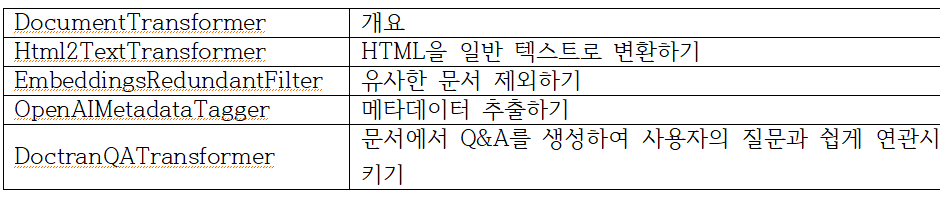

### 3.Text embedding models

In [ ]:
문서 변환 처리를 마쳤다면 텍스트를 벡터화할 차례다.<br />
재미나이의 Embeddings API를 사용하여 `gemini-embedding-001`라는 모델로 텍스트를 벡터화한다. <br />   

LangChain에는 재마나이의 Embeddings API를 래핑한 `GoogleGenerativeAIEmbeddings`라는 클래스가 있다.<br /> `GoogleGenerativeAIEmbeddings`도 마찬가지로 텍스트 벡터화에 사용할 수 있는 것이 ‘Text embedding models’다

In [16]:
import os
# 1. API 키 설정 (보안을 위해 사용 후 노출되지 않도록 주의하세요!)
os.environ["GOOGLE_API_KEY"] = "your_api_key"

# 2. 가장 최신의 공식 권장 클래스 임포트
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# 3. 임베딩 모델 선언
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
# 또는 최신 프리뷰 모델을 원하시면 아래 모델을 사용하셔도 됩니다.
# embeddings =
# GoogleGenerativeAIEmbeddings(model="gemini-embedding-2-preview")

문서의 벡터화 처리는 다음에 설명할 Vector store 클래스에 데이터를 저장할 때 내부적으로 수행된다.<br />
그러나 이러한 설명만으로는 벡터화의 구체적인 과정을 상상하기 어려울 수 있으므로, 여기서 벡터화를 직접 시도해 보겠다.

In [ ]:
이후의 코드를 실행하려면 `tiktoken`이라는 패키지가 필요하므로 다음과 같이 `tiktoken`을 설치한다.⁷

In [17]:
!pip install tiktoken==0.6.0

   ---------------------------------------- 0.0/798.7 kB ? eta -:--:--
   ---------------------------------------- 798.7/798.7 kB 11.4 MB/s  0:00:00


`GoogleGenerativeAIEmbeddings`를 사용해 텍스트를 벡터화해 보자.

In [18]:
query = "AWS S3에서 데이터를 불러올 수 있는 DocumentLoader가 있나요?"

# 3. 임베딩 벡터 생성
vector = embeddings.embed_query(query)
print("벡터 차원 크기:", len(vector))
print("벡터 데이터 일부:", vector[:5])

벡터 차원 크기: 3072
벡터 데이터 일부: [0.026992848, 0.015734974, 0.01939729, -0.06874713, -0.012229344]


'AWS S3에서 데이터를 불러올 수 있는 DocumentLoader가 있나요?'라는 문자열이 3072차원의 벡터(숫자 목록)로 변환되었다.

### 반드시 GitLoader -> CharacterTextSplitter -> GoogleGenerativeAIEmbeddings 순서로 진행해야 합니다.
<br /><br />
데이터는 단계별로 형태가 완전히 변하기 때문에, 앞 단계의 결과물이 있어야만 다음 단계가 작동할 수 있습니다.<br />
1. GitLoader (재료 수집): 인터넷(깃허브)에 있는 원격 코드나 마크다운 파일을 내 컴퓨터 메모리로 가져와 하나의 긴 텍스트 묶음(Document 객체)으로 만듭니다.
(아직은 가공되지 않은 통째로의 서류철입니다.)<br />
2. CharacterTextSplitter (크기 조절): 너무 길어서 AI 모델이 한 번에 읽지 못하는 원본 서류철을 1,000자나 500자 같이 AI가 소화하기 좋은 적당한 크기의 조각(Chunk)으로 싹둑싹둑 자릅니다.<br />
3. GoogleGenerativeAIEmbeddings (수학적 가공): 잘게 쪼개진 글자(텍스트) 조각들을 컴퓨터가 이해하고 검색할 수 있는 수학적 숫자 좌표(벡터)로 변환합니다.

In [21]:
!pip install -qU langchain-community langchain-text-splitters langchain-google-genai GitPython

In [24]:
import os
os.environ["GOOGLE_API_KEY"] = "your_api_key"

from langchain_community.document_loaders import GitLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# 구글 API 키 설정 (본인의 API 키를 입력하거나 .env 파일을 사용하세요)
# os.environ["GOOGLE_API_KEY"] = "your-gemini-api-key-here"

# ---------------------------------------------------------------------
# 단계 1: GitLoader (재료 수집)
# ---------------------------------------------------------------------
print("단계 1️: GitLoader를 사용해 깃허브에서 마크다운 문서를 다운로드하는 중...")

def markdown_filter(file_path):
    return file_path.endswith(".md")

loader = GitLoader(
    clone_url="https://github.com/langchain-ai/langchain",
    repo_path="./langchain_data",
    branch="master",
    file_filter=markdown_filter,
)
raw_documents = loader.load()
print(f" [수집 완료] 원본 마크다운 파일 개수: {len(raw_documents)}개")
print("-" * 50)


# ---------------------------------------------------------------------
# 단계 2: CharacterTextSplitter (크기 조절)
# ---------------------------------------------------------------------
print("단계 2️: CharacterTextSplitter를 사용해 긴 문서를 1000자 단위로 쪼개는 중...")

# 1000자 단위로 자르되, 의미가 끊어지지 않도록 앞뒤로 100자씩 겹치게(Overlap) 설정합니다.
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
split_documents = text_splitter.split_documents(raw_documents)

print(f" [가공 완료] 쪼개진 후 생성된 총 텍스트 조각(Chunk) 개수: {len(split_documents)}개")
print("-" * 50)


# ---------------------------------------------------------------------
# 단계 3: GoogleGenerativeAIEmbeddings (수학적 가공)
# ---------------------------------------------------------------------
print("단계 3️: GoogleGenerativeAIEmbeddings를 사용해 텍스트 조각을 숫자(벡터)로 변환하는 중...")

# 구글의 최신 텍스트 임베딩 모델을 호출합니다.
embeddings_model = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

# 테스트를 위해 전체 중 첫 번째 조각 1개만 골라서 숫자로 변환해봅니다.
sample_text = split_documents[0].page_content

# embed_query 함수를 사용하면 텍스트가 수많은 소수점 숫자가 담긴 리스트(벡터)로 변환됩니다.
vector_result = embeddings_model.embed_query(sample_text)

print(" [변환 완료] 첫 번째 텍스트 조각이 성공적으로 컴퓨터가 이해하는 숫자로 바뀌었습니다!")
print(f" 첫 번째 텍스트 조각의 글자 수: {len(sample_text)}자")
print(f" 변환된 숫자(벡터)의 차원 크기: {len(vector_result)}차원")
print(f" 변환된 숫자 일부 샘플 (앞 5개): {vector_result[:5]}")

단계 1️: GitLoader를 사용해 깃허브에서 마크다운 문서를 다운로드하는 중...


Created a chunk of size 1455, which is longer than the specified 1000


 [수집 완료] 원본 마크다운 파일 개수: 29개
--------------------------------------------------
단계 2️: CharacterTextSplitter를 사용해 긴 문서를 1000자 단위로 쪼개는 중...
 [가공 완료] 쪼개진 후 생성된 총 텍스트 조각(Chunk) 개수: 124개
--------------------------------------------------
단계 3️: GoogleGenerativeAIEmbeddings를 사용해 텍스트 조각을 숫자(벡터)로 변환하는 중...
 [변환 완료] 첫 번째 텍스트 조각이 성공적으로 컴퓨터가 이해하는 숫자로 바뀌었습니다!
 첫 번째 텍스트 조각의 글자 수: 312자
 변환된 숫자(벡터)의 차원 크기: 3072차원
 변환된 숫자 일부 샘플 (앞 5개): [-0.011593239, 0.017252676, 0.00092127087, -0.056006674, -0.020663999]
